In [16]:
import numpy as np
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import os.path as op
from  nilearn.datasets import fetch_surf_fsaverage
from  nilearn import image
import pandas as pd 

fsaverage = fetch_surf_fsaverage() #fsavergae5 by default

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'

from utils_02 import get_GMmargulies_cmap 
cmap_marg = get_GMmargulies_cmap() 


Just mean signal divided by std

Maybe you want to regress out some confound but then you have to add the mean signal again after that. Shouldn't matter too much.
So nilearn.image, use `image.math_img` to divide mean by std and then write it to a nifty and/or use nilearn.plotting to make a plot with colorbar
Maybe once try it after running nilearn.clean_img with the confound regressors or something.

In [52]:
sub = '02'
ses = 1
run=1
space = 'fsaverage5'
hemi = 'R'
ex_file = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-1_space-{space}_hemi-{hemi}_bold.func.gii') 

ts = nib.load(ex_file).agg_data()
print(ts.shape)

snr = np.mean(ts, axis=1)/np.std(ts, axis=1)

(10242, 135)


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_65676/2393405752.py:11: RuntimeWarning: invalid value encountered in true_divide
  snr = np.mean(ts, axis=1)/np.std(ts, axis=1)


In [ ]:
# all runs
number_of_vertex =10242

clean_ts_runs = np.empty([number_of_vertex,0])
for run in range(1,7):
    ts_run = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-1_space-{space}_hemi-{hemi}_bold.func.gii') 
    

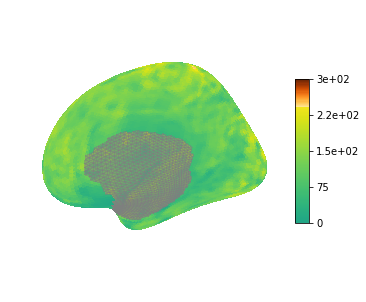

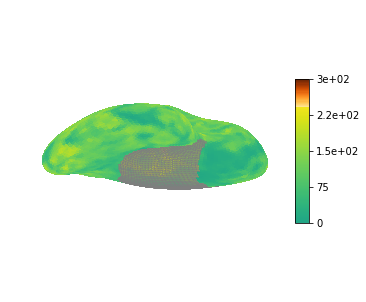

In [53]:
cmap = cmap_marg # 'viridis'
surf_mesh = fsaverage.infl_right
view = 'lateral'
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, stat_map=snr,cmap=cmap,view=view)
plt.show()
view = 'ventral'
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, stat_map=snr,cmap=cmap,view=view)
plt.show()

In [54]:
from nilearn import signal

fmriprep_confounds_include = ['global_signal', 'dvars', 'framewise_displacement', 'trans_x',
                'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
                'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'cosine00', 'cosine01', 'cosine02'
                ]

fmriprep_confounds_file = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_desc-confounds_timeseries.tsv')
fmriprep_confounds = pd.read_table(fmriprep_confounds_file)[fmriprep_confounds_include] 
fmriprep_confounds= fmriprep_confounds.fillna(method='bfill')

clean_ts = signal.clean(ts.T, confounds=fmriprep_confounds).T

snr_clean = (np.mean(clean_ts, axis=1)/np.std(clean_ts, axis=1)) + np.mean(ts, axis=1)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_65676/3089426612.py:14: RuntimeWarning: invalid value encountered in true_divide
  snr_clean = (np.mean(clean_ts, axis=1)/np.std(clean_ts, axis=1)) + np.mean(ts, axis=1)


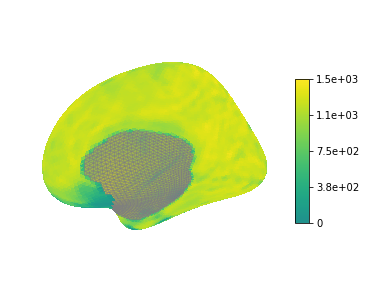

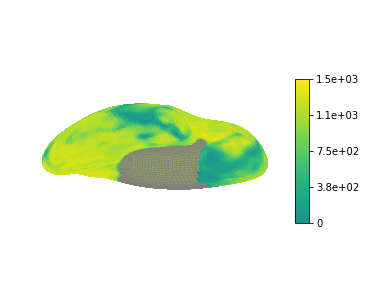

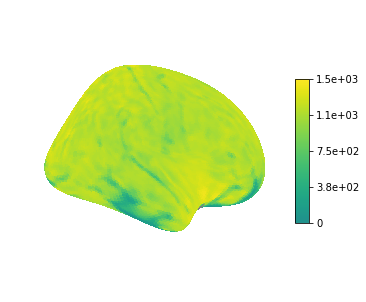

In [55]:
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, stat_map=snr_clean,cmap='viridis',view='lateral')
plt.show()
view = 'ventral'
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, stat_map=snr_clean,cmap='viridis',view=view)
plt.show()
view = 'medial'
nplt.plot_surf_stat_map(surf_mesh=surf_mesh, stat_map=snr_clean,cmap='viridis',view=view)
plt.show()